# Import Library

In [ ]:
!pip install Sastrawi nltk emoji wordcloud gensim requests

In [ ]:
import re
import pandas as pd
import nltk
import emoji
import html
import requests

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Loading Dataset

In [ ]:
df = pd.read_csv("ulasan_aplikasi.csv")
df.head()

,Review
0,mantap ruang guru
1,karena harus bayar jadi plis jangan harus bayar
2,"bagus banget loh ya, Vdio nya muter terus kata..."
3,sangat membantu terima kasih
4,aplikasinya ga nyaman banget. setiap masuk sel...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  15000 non-null  object
dtypes: object(1)
memory usage: 117.3+ KB


In [ ]:
df = df.dropna().drop_duplicates().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12694 entries, 0 to 12693
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  12694 non-null  object
dtypes: object(1)
memory usage: 99.3+ KB


# Preprocessing

In [ ]:
import requests

# 1. First slang txt
url1 = 'https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/cdf127872143a57a9a53f34735bca44c8206b696/combined_slang_words.txt'
resp1 = requests.get(url1)

mapper_dict1 = {}
for line in resp1.text.splitlines():
    if line.strip():
        key, value = line.split(',', 1)
        mapper_dict1[key.strip()] = value.strip()

url2 = 'https://raw.githubusercontent.com/okkyibrohim/id-abusive-language-detection/refs/heads/master/kamusalay.csv'
resp2 = requests.get(url2)

mapper_dict2 = {}
for line in resp2.text.splitlines():
    if line.strip():
        key, value = line.split(',', 1)
        mapper_dict2[key.strip()] = value.strip()

combined_slang_map = {**mapper_dict1, **mapper_dict2}

print(f"Combined slang map contains {len(combined_slang_map)} entries.")
print(list(combined_slang_map.items())[:5])

Combined slang map contains 238 entries.
[('{"@": "di"', '"abis": "habis", "ad": "ada", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "bere

In [ ]:
def clean_char(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'[^A-Za-z0-9 ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['Review'].apply(clean_char)

df[['Review','cleaned_text']].head()

,Review,cleaned_text
0,mantap ruang guru,mantap ruang guru
1,karena harus bayar jadi plis jangan harus bayar,karena harus bayar jadi plis jangan harus bayar
2,"bagus banget loh ya, Vdio nya muter terus kata...",bagus banget loh ya Vdio nya muter terus katan...
3,sangat membantu terima kasih,sangat membantu terima kasih
4,aplikasinya ga nyaman banget. setiap masuk sel...,aplikasinya ga nyaman banget setiap masuk sela...


In [ ]:
pattern = re.compile(
    r"\b(" + "|".join(re.escape(s) for s in combined_slang_map.keys()) + r")\b",
    flags=re.IGNORECASE
)

def slang_map_fast(text):
    return pattern.sub(lambda m: combined_slang_map[m.group(0).lower()], text.lower())

df['slang_corrected'] = df['cleaned_text'].apply(slang_map_fast)
df[['cleaned_text', 'slang_corrected']].head()

,cleaned_text,slang_corrected
0,mantap ruang guru,mantap ruang guru
1,karena harus bayar jadi plis jangan harus bayar,karena harus bayar jadi plis jangan harus bayar
2,bagus banget loh ya Vdio nya muter terus katan...,bagus banget loh ya vdio nya muter terus katan...
3,sangat membantu terima kasih,sangat membantu terima kasih
4,aplikasinya ga nyaman banget setiap masuk sela...,aplikasinya tidak nyaman banget setiap masuk s...


In [ ]:
import emoji
def emoji_rm(text):
  text = emoji.replace_emoji(text, replace="")
  return text

df['emoji_removed'] = df['slang_corrected'].apply(emoji_rm)

In [ ]:
df.sample(5)

,Review,cleaned_text,slang_corrected,emoji_removed
12297,Bagus banget buat ibu ibu di rumah buat anak n...,Bagus banget buat ibu ibu di rumah buat anak n...,bagus banget buat ibu ibu di rumah buat anak n...,bagus banget buat ibu ibu di rumah buat anak n...
2258,sangat membantu apalagi sekarang dekat ujian i...,sangat membantu apalagi sekarang dekat ujian i...,sangat membantu apalagi sekarang dekat ujian i...,sangat membantu apalagi sekarang dekat ujian i...
9302,"Setelah di update malah kebanyak macet,padahal...",Setelah di update malah kebanyak macet padahal...,setelah di update malah kebanyak macet padahal...,setelah di update malah kebanyak macet padahal...
6454,Sangat berguna sekali aplikasi ini membantu un...,Sangat berguna sekali aplikasi ini membantu un...,sangat berguna sekali aplikasi ini membantu un...,sangat berguna sekali aplikasi ini membantu un...
10232,SENANG BELAJAR DI RUANG GURU MEMUASKAN TAPI PE...,SENANG BELAJAR DI RUANG GURU MEMUASKAN TAPI PE...,senang belajar di ruang guru memuaskan tapi pe...,senang belajar di ruang guru memuaskan tapi pe...


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize

df['tokenized_text'] = df['emoji_removed'].apply(word_tokenize)

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

sw = set(stopwords.words('indonesian'))
sw.update(['nya', 'ko'])

def stopwords_rm(text):
  return [word for word in text if word not in sw]


df['stopwords_removed'] = df['tokenized_text'].apply(stopwords_rm)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
!pip install pySastrawi Levenshtein
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git
!pip install indoNLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.3 MB/s eta 0:00:00
  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-52_36i2r
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-52_36i2r
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99799 sha256=f8995ceafa562ca88a01554da179b04decb7fcdc5f133999337de24c134c66b1
  Stored in directory: /tmp/pip-ephem-wheel-cache-ok0nsc26/wheels/85/1f/78/fccc1e7e90613593e0a66304a3711d678e3013034d91534182
Successfully built mpstemmer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 6.0 MB/s eta 0:00:00


In [ ]:
from mpstemmer import MPStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()
stemmer2 = MPStemmer()

def stemming_mps(list_of_words):
  return ' '.join([stemmer2.stem(word) for word in list_of_words])

def stemming_sastrawi(list_of_words):
  return ' '.join([stemmer.stem(word) for word in list_of_words])

df['stemmed_text'] = df['stopwords_removed'].apply(stemming_mps)
df['stemmed_text_sastrawi'] = df['stopwords_removed'].apply(stemming_sastrawi)

In [ ]:
df.sample(5)

,Review,cleaned_text,slang_corrected,emoji_removed,tokenized_text,stopwords_removed,stemmed_text,stemmed_text_sastrawi
4163,"Apk nyaa kerennn,makasih ruang guru ,membantu ...",Apk nyaa kerennn makasih ruang guru membantu a...,apk nyaa kerennn makasih ruang guru membantu a...,apk nyaa kerennn makasih ruang guru membantu a...,"[apk, nyaa, kerennn, makasih, ruang, guru, mem...","[apk, nyaa, kerennn, makasih, ruang, guru, mem...",apk saa rennn memakasih ruang guru bantu ajar ...,apk nyaa kerennn makasih ruang guru bantu ajar...
7965,Bisa bisa☆☆,Bisa bisa,bisa bisa,bisa bisa,"[bisa, bisa]",[],,
8339,Membantu👍,Membantu,membantu,membantu,[membantu],[membantu],bantu,bantu
10630,Bagus buat belajar sd smp sma cocok yang lagi ...,Bagus buat belajar sd smp sma cocok yang lagi ...,bagus buat belajar sd smp sma cocok yang lagi ...,bagus buat belajar sd smp sma cocok yang lagi ...,"[bagus, buat, belajar, sd, smp, sma, cocok, ya...","[bagus, belajar, sd, smp, sma, cocok, ulangan]",bagus ajar sd smp sma cocok ulang,bagus ajar sd smp sma cocok ulang
10776,Sangat luar biasa pelajarannya yang di ajarakan,Sangat luar biasa pelajarannya yang di ajarakan,sangat luar biasa pelajarannya yang di ajarakan,sangat luar biasa pelajarannya yang di ajarakan,"[sangat, luar, biasa, pelajarannya, yang, di, ...","[pelajarannya, ajarakan]",pelajar ajarakan,ajar ajarakan


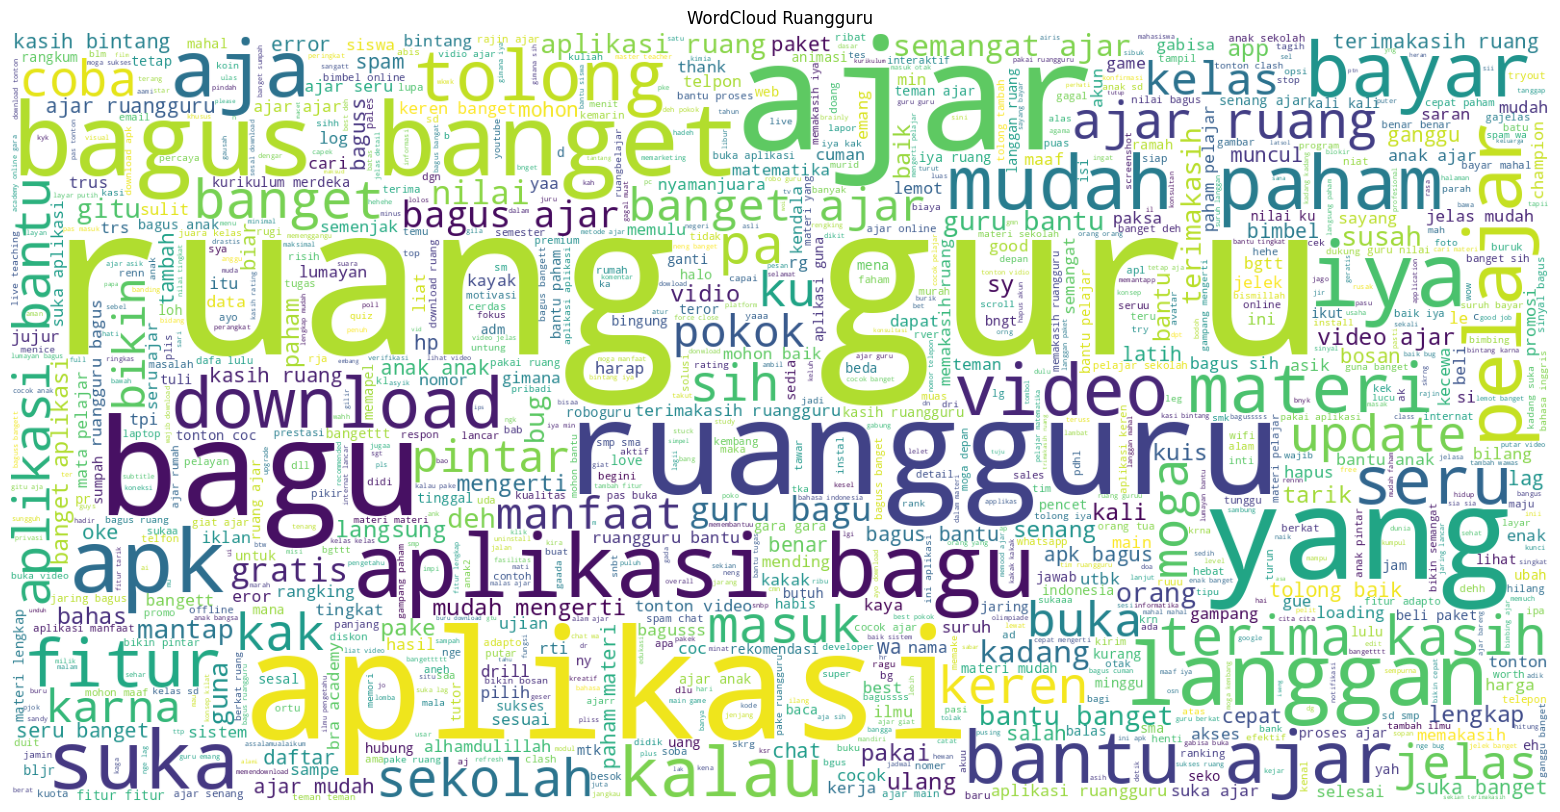

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

processed_text = ' '.join(df['stemmed_text'].astype(str).tolist())

wc = WordCloud(max_words=1000, width=1600, height=800
               , background_color = 'white')

plt.figure(figsize=(20, 10))
plt.imshow(wc.generate(processed_text))
plt.axis('off')
plt.title('WordCloud Ruangguru')
plt.show()

# Labelling

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

mname = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer = AutoTokenizer.from_pretrained(mname)
model = AutoModelForSequenceClassification.from_pretrained(mname)
sentimen_clf = pipeline(
    'sentiment-analysis',
    model=model,
    tokenizer = tokenizer,
    max_length = 512,
    truncation=True
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test = sentimen_clf("produk ini bagus sekali", return_all_scores=True)
print(test)

[{'label': 'positive', 'score': 0.9950950145721436}]


In [ ]:
texts = df['stemmed_text_sastrawi'].fillna('').astype(str).tolist()
results = sentimen_clf(texts, batch_size=32)
binary_labels = []

for res in results:
    label = res['label']
    if label == 'positive':
        binary_labels.append('positive')
    else:
        binary_labels.append('negative')

df['sentiment'] = binary_labels

In [ ]:
df.columns

Index(['Review', 'cleaned_text', 'slang_corrected', 'emoji_removed',
       'tokenized_text', 'stopwords_removed', 'stemmed_text',
       'stemmed_text_sastrawi'],
      dtype='object')

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,7224
positive,5470


# Modelling

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

In [ ]:
y = df['sentiment_encoded']
x = df['stemmed_text_sastrawi']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF + SVM

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf1 = TfidfVectorizer(max_features=5000)

tfidf_train = tfidf1.fit_transform(x_train)
tfidf_test = tfidf1.transform(x_test)

In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report

svm = LinearSVC()

svm.fit(tfidf_train, y_train)
y_pred_tfidf_svm = svm.predict(tfidf_test)
print('\nClassification Report\n')
print(classification_report(y_test, y_pred_tfidf_svm))


Classification Report

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1445
           1       0.83      0.81      0.82      1094

    accuracy                           0.85      2539
   macro avg       0.85      0.84      0.84      2539
weighted avg       0.85      0.85      0.85      2539



# TF-IDF + LogReg

In [ ]:
from sklearn.linear_model import LogisticRegression


logreg = LogisticRegression(random_state=42, max_iter=5000)
logreg.fit(tfidf_train, y_train)

# 4. Predict and evaluate
y_pred_lgr = logreg.predict(tfidf_test)
print(classification_report(y_test, y_pred_lgr))

              precision    recall  f1-score   support

    negative       0.85      0.91      0.88      1445
    positive       0.87      0.79      0.83      1094

    accuracy                           0.86      2539
   macro avg       0.86      0.85      0.85      2539
weighted avg       0.86      0.86      0.86      2539



# LTSM

In [ ]:
import numpy as np
import tensorflow as tf
import random

# Fix random seed biar stabil
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(input_dim=25000, output_dim=128),

    Bidirectional(
        LSTM(64, return_sequences=True)   # ⬅ Turunkan dari 128 → 64
    ),

    GlobalMaxPooling1D(),   # ⬅ Lebih kuat untuk sentiment
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # ⬅ Turunkan LR
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6168 - loss: 0.6541 - val_accuracy: 0.8272 - val_loss: 0.4109
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8317 - loss: 0.4066 - val_accuracy: 0.8597 - val_loss: 0.3335
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8816 - loss: 0.2998 - val_accuracy: 0.8671 - val_loss: 0.3283
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9074 - loss: 0.2326 - val_accuracy: 0.8587 - val_loss: 0.3417
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9248 - loss: 0.1953 - val_accuracy: 0.8705 - val_loss: 0.3577
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      1445
           1       0.81      0.86      0.83      1094

    accuracy                           0.85      2539
   macro avg       0.85      0.85      0.85      2539
weighted avg       0.85      0.85      0.85 

In [ ]:
def predict_sentiment(text):
    # preprocessing sama seperti training
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    prob = model.predict(padded)[0][0]

    if prob > 0.5:
        return "positive"
    else:
        return "negative"

In [ ]:
print(predict_sentiment("produk ini sangat bagus dan berkualitas"))
print(predict_sentiment("pelayanan sangat mengecewakan dan lambat"))
print(predict_sentiment("biasa saja tidak terlalu istimewa"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
negative


In [1]:
!pip install pipreqs

In [2]:
!pipreqs "/content/drive/MyDrive/Colab Notebooks/Analyst Sentimen" --scan-notebooks

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in /content/drive/MyDrive/Colab Notebooks/Analyst Sentimen/requirements.txt
